In [15]:
import pandas as pd
import pathlib
from pathlib import Path
from glob import glob
import json
import os

In [16]:
def read_states_run(run_path: pathlib.PosixPath):
    properties_file = run_path / "static-properties"
    state_file = run_path / "state_data.csv"
    plan_file = run_path / "sas_plan"
    if not os.path.isfile(properties_file) or \
        not os.path.isfile(state_file):
        return pd.DataFrame()

    properties = None
    with open(properties_file) as file:
        properties = json.load(file)
    
    df = pd.read_csv(state_file)
    df['domain'] = properties['domain']
    df['problem'] = properties['problem']
    df['solved'] = os.path.isfile(plan_file)
    return df

def read_states_domain(exp_data: pathlib.PosixPath):
    search_glob = map(Path, glob(str(exp_data / "runs-*" / "*")))
    
    dfs = []
    for run_path in search_glob:
        dfs.append(read_states_run(run_path))
    return dfs

In [17]:
example =   read_states_domain(pathlib.Path('./data/2025-04-20-A-state_extraction'))[0]

example.loc[0, "var0"] = example.loc[0, "buff0"]
for i in range(13):
    example.loc[0, f"var{i+1}"] = example.loc[0, f"var{i}"]

example['var13'] = example['var13'].astype(int)
example 

,index,sequence,buff0,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13,domain,problem,solved
0,-1,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,depot,p01.pddl,True
1,1,0,202855,0,2,1,1,0,0,0,0,1,0,0,0,7,6,depot,p01.pddl,True
2,2,0,203111,1,2,1,1,0,0,0,0,1,0,0,0,7,6,depot,p01.pddl,True
3,3,0,203367,2,2,1,1,0,0,0,0,1,0,0,0,7,6,depot,p01.pddl,True
4,4,0,200807,0,0,1,1,0,0,0,0,1,0,0,0,7,6,depot,p01.pddl,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,395,1,6601348,2,2,0,0,1,0,0,1,3,2,1,0,4,8,depot,p01.pddl,True
196,396,1,14219826,2,2,0,0,0,1,1,0,3,3,1,1,2,3,depot,p01.pddl,True
197,397,1,9553974,0,2,1,0,0,0,1,0,0,3,0,1,6,3,depot,p01.pddl,True
198,398,1,4880498,0,2,0,1,0,1,0,0,3,1,1,0,2,7,depot,p01.pddl,True


In [ ]:
df = example.loc[1:, "var0":"var13"].copy(deep=True)
domain_sizes = example.loc[0, "var0":"var13"]

df, domain_sizes

df = example.loc[1:, "pa":"var13"].copy(deep=True)
domain_sizes = example.loc[0, "var0":"var13"]

df, domain_sizes

(     var0  var1  var2  var3  var4  var5  var6  var7  var8  var9  var10  var11  \
 1       0     2     1     1     0     0     0     0     1     0      0      0   
 2       1     2     1     1     0     0     0     0     1     0      0      0   
 3       2     2     1     1     0     0     0     0     1     0      0      0   
 4       0     0     1     1     0     0     0     0     1     0      0      0   
 5       0     1     1     1     0     0     0     0     1     0      0      0   
 ..    ...   ...   ...   ...   ...   ...   ...   ...   ...   ...    ...    ...   
 195     2     2     0     0     1     0     0     1     3     2      1      0   
 196     2     2     0     0     0     1     1     0     3     3      1      1   
 197     0     2     1     0     0     0     1     0     0     3      0      1   
 198     0     2     0     1     0     1     0     0     3     1      1      0   
 199     2     2     0     1     0     0     0     1     3     1      1      0   
 
      var12  v

In [19]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# Assume df and domain_sizes are defined

cols = df.columns
n = len(cols)
obs_ratio_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)

for i in range(n):
    for j in range(n):
        if i == j:
            obs_ratio_matrix.iloc[i, j] = np.nan
            continue
        col_i, col_j = cols[i], cols[j]
        observed = df[[col_i, col_j]].drop_duplicates()
        actual_count = len(observed)
        possible_count = domain_sizes[col_i] * domain_sizes[col_j]
        ratio = actual_count / possible_count if possible_count > 0 else np.nan
        obs_ratio_matrix.iloc[i, j] = ratio

# Display the title and matrix in Jupyter
display(Markdown('## Ratio of Observed to Potential Value Pairs for Each Variable Pair'))
display(
    obs_ratio_matrix.style
        .format("{:.2%}")
        .background_gradient(cmap="YlGn")
)

## Ratio of Observed to Potential Value Pairs for Each Variable Pair

,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13
var0,nan%,100.00%,66.67%,66.67%,66.67%,66.67%,66.67%,66.67%,133.33%,133.33%,66.67%,66.67%,266.67%,266.67%
var1,100.00%,nan%,66.67%,66.67%,66.67%,66.67%,66.67%,66.67%,133.33%,133.33%,66.67%,66.67%,266.67%,266.67%
var2,66.67%,66.67%,nan%,44.44%,33.33%,44.44%,44.44%,44.44%,66.67%,55.56%,44.44%,44.44%,155.56%,133.33%
var3,66.67%,66.67%,44.44%,nan%,33.33%,44.44%,44.44%,44.44%,55.56%,66.67%,44.44%,44.44%,144.44%,155.56%
var4,66.67%,66.67%,33.33%,33.33%,nan%,44.44%,33.33%,44.44%,55.56%,55.56%,44.44%,44.44%,122.22%,133.33%
var5,66.67%,66.67%,44.44%,44.44%,44.44%,nan%,44.44%,44.44%,88.89%,77.78%,44.44%,44.44%,155.56%,155.56%
var6,66.67%,66.67%,44.44%,44.44%,33.33%,44.44%,nan%,44.44%,77.78%,77.78%,44.44%,44.44%,144.44%,144.44%
var7,66.67%,66.67%,44.44%,44.44%,44.44%,44.44%,44.44%,nan%,77.78%,88.89%,44.44%,44.44%,144.44%,155.56%
var8,133.33%,133.33%,66.67%,55.56%,55.56%,88.89%,77.78%,77.78%,nan%,88.89%,44.44%,66.67%,88.89%,244.44%
var9,133.33%,133.33%,55.56%,66.67%,55.56%,77.78%,77.78%,88.89%,88.89%,nan%,66.67%,44.44%,244.44%,88.89%


In [20]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# Assume df is your DataFrame of categorical variables

cols = df.columns
n = len(cols)

# Compute domain sizes as number of unique values in each column
domain_sizes = df.nunique()

obs_ratio_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)

for i in range(n):
    for j in range(n):
        if i == j:
            obs_ratio_matrix.iloc[i, j] = np.nan
            continue
        col_i, col_j = cols[i], cols[j]
        observed = df[[col_i, col_j]].drop_duplicates()
        actual_count = len(observed)
        possible_count = domain_sizes[col_i] * domain_sizes[col_j]
        ratio = actual_count / possible_count if possible_count > 0 else np.nan
        obs_ratio_matrix.iloc[i, j] = ratio

# Display with title in Jupyter
display(Markdown("## Ratio of Observed to Possible Value Pairs (based on sampled range)"))
display(
    obs_ratio_matrix.style
        .format("{:.2%}")
        .background_gradient(cmap="YlGn")
)

## Ratio of Observed to Possible Value Pairs (based on sampled range)

,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13
var0,nan%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%
var1,100.00%,nan%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%
var2,100.00%,100.00%,nan%,100.00%,75.00%,100.00%,100.00%,100.00%,75.00%,62.50%,100.00%,100.00%,87.50%,75.00%
var3,100.00%,100.00%,100.00%,nan%,75.00%,100.00%,100.00%,100.00%,62.50%,75.00%,100.00%,100.00%,81.25%,87.50%
var4,100.00%,100.00%,75.00%,75.00%,nan%,100.00%,75.00%,100.00%,62.50%,62.50%,100.00%,100.00%,68.75%,75.00%
var5,100.00%,100.00%,100.00%,100.00%,100.00%,nan%,100.00%,100.00%,100.00%,87.50%,100.00%,100.00%,87.50%,87.50%
var6,100.00%,100.00%,100.00%,100.00%,75.00%,100.00%,nan%,100.00%,87.50%,87.50%,100.00%,100.00%,81.25%,81.25%
var7,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,nan%,87.50%,100.00%,100.00%,100.00%,81.25%,87.50%
var8,100.00%,100.00%,75.00%,62.50%,62.50%,100.00%,87.50%,87.50%,nan%,50.00%,50.00%,75.00%,25.00%,68.75%
var9,100.00%,100.00%,62.50%,75.00%,62.50%,87.50%,87.50%,100.00%,50.00%,nan%,75.00%,50.00%,68.75%,25.00%


In [21]:
from itertools import combinations

cols = [col for col in df.columns if col not in ['sequence', 'id']]
block_ratios = dict()
max_block_size = 4
# Precompute ratios for all blocks size 2-4
for size in range(2, max_block_size+1):
    for block in combinations(cols, size):
        block = tuple(sorted(block))
        observed = len(df[list(block)].drop_duplicates())
        possible = np.prod([df[c].nunique() for c in block])
        ratio = observed / possible if possible > 0 else np.nan
        block_ratios[block] = ratio

available = set(cols)
partition = []
while available:
    best_block = None
    best_ratio = None
    for size in range(max_block_size, 1, -1):
        for block in combinations(sorted(available), size):
            ratio = block_ratios.get(tuple(sorted(block)), np.nan)
            if np.isnan(ratio): continue
            if (best_ratio is None) or (ratio < best_ratio):
                best_block = block
                best_ratio = ratio
        if best_block is not None:
            break
    # Fallback: singleton
    if best_block is None:
        single_var = sorted(available)[0]
        partition.append((single_var,))
        available.remove(single_var)
    else:
        partition.append(best_block)
        for v in best_block: available.remove(v)

ratios = []
observed_counts = []
possible_counts = []
block_labels = []
for group in partition:
    group_list = list(group) if isinstance(group, tuple) else [group]
    observed = len(df[group_list].drop_duplicates())
    possible = np.prod([df[c].nunique() for c in group_list])
    ratio = observed / possible if possible > 0 else np.nan
    ratios.append(ratio)
    observed_counts.append(observed)
    possible_counts.append(possible)
    block_labels.append(str(group))

ratios_series = pd.Series(ratios, index=block_labels).dropna()
mean_ratio = np.mean(ratios)
variance_ratio = np.var(ratios)
quantiles = pd.Series(ratios).quantile([0, 0.25, 0.5, 0.75, 1.0])
overall_ratio = np.prod(ratios)

import pandas as pd
from IPython.display import display, Markdown
summary = pd.DataFrame({
    'Statistic': [
        "Mean per-block ratio",
        "Variance per-block ratio",
        "0% (min)", "25%", "50% (median)", "75%", "100% (max)",
        "Overall product ratio (blockwise)"
    ],
    'Value': [
        mean_ratio,
        variance_ratio,
        quantiles.iloc[0],
        quantiles.iloc[1],
        quantiles.iloc[2],
        quantiles.iloc[3],
        quantiles.iloc[4],
        overall_ratio
    ]
})

display(Markdown("## Greedy Best Partition (Block ≤ 4 vars, Minimum Product Ratio)"))
display(summary)

# Per block table
per_block_table = pd.DataFrame({
    "Block": block_labels,
    "Observed": observed_counts,
    "Possible": possible_counts,
    "Ratio": ratios
})
display(Markdown("### Greedy Chosen Blocks:"))
display(per_block_table.style)

## Greedy Best Partition (Block ≤ 4 vars, Minimum Product Ratio)

,Statistic,Value
0,Mean per-block ratio,0.541504
1,Variance per-block ratio,0.117350
2,0% (min),0.041016
3,25%,0.385254
4,50% (median),0.562500
5,75%,0.718750
6,100% (max),1.000000
7,Overall product ratio (blockwise),0.012817


### Greedy Chosen Blocks:

,Block,Observed,Possible,Ratio
0,"('var12', 'var13', 'var8', 'var9')",42,1024,0.041016
1,"('var10', 'var11', 'var2', 'var3')",8,16,0.500000
2,"('var4', 'var5', 'var6', 'var7')",10,16,0.625000
3,"('var0', 'var1')",9,9,1.000000


In [22]:
from itertools import combinations, chain
def all_partitions(lst, max_block=4):
    """Yield all partitions of lst into blocks of size at most max_block."""
    if not lst:
        yield []
        return
    n = len(lst)
    for size in range(1, min(max_block, n) + 1):
        for first in combinations(lst, size):
            rest = [x for x in lst if x not in first]
            for partition in all_partitions(rest, max_block):
                yield [tuple(first)] + partition

In [23]:
from scipy.stats import entropy

def conditional_entropy(x, y):
    # x, y are pandas Series of equal length
    y_unique = y.unique()
    ce = 0
    for yv in y_unique:
        x_sub = x[y == yv]
        if len(x_sub) == 0: continue
        ce += len(x_sub)/len(x) * entropy(pd.value_counts(x_sub, normalize=True), base=2)
    return ce

ce_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)
for i, v in enumerate(cols):
    for j, w in enumerate(cols):
        if i != j:
            ce = conditional_entropy(df[v], df[w])
            ce_matrix.iloc[i, j] = ce

display(Markdown("## Conditional Entropy H(X|Y) Matrix (bits):"))
display(
    ce_matrix.style
        .background_gradient(cmap="YlOrBr", axis=None)
        .format("{:.3f}")
)

/tmp/ipykernel_9162/2939334780.py:10: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  ce += len(x_sub)/len(x) * entropy(pd.value_counts(x_sub, normalize=True), base=2)


## Conditional Entropy H(X|Y) Matrix (bits):

,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13
var0,nan,1.576,1.578,1.579,1.577,1.578,1.578,1.573,1.566,1.573,1.577,1.577,1.558,1.562
var1,1.574,nan,1.577,1.577,1.578,1.572,1.577,1.569,1.567,1.573,1.574,1.575,1.555,1.543
var2,0.828,0.828,nan,0.809,0.762,0.761,0.824,0.780,0.655,0.323,0.821,0.661,0.613,0.301
var3,0.876,0.877,0.857,nan,0.799,0.863,0.845,0.857,0.363,0.687,0.712,0.864,0.348,0.684
var4,0.583,0.586,0.519,0.508,nan,0.577,0.522,0.579,0.305,0.338,0.570,0.578,0.240,0.314
var5,0.827,0.822,0.761,0.815,0.819,nan,0.827,0.807,0.821,0.693,0.823,0.697,0.569,0.380
var6,0.811,0.812,0.808,0.782,0.749,0.811,nan,0.807,0.710,0.783,0.718,0.806,0.322,0.573
var7,0.618,0.615,0.575,0.604,0.617,0.602,0.618,nan,0.583,0.579,0.590,0.582,0.305,0.366
var8,1.420,1.423,1.260,0.920,1.152,1.426,1.331,1.393,nan,1.264,0.494,1.306,0.000,1.207
var9,1.407,1.409,0.908,1.223,1.165,1.277,1.384,1.369,1.244,nan,1.281,0.487,1.080,0.000


In [24]:
domain_sizes = df.nunique()
obs_ratio_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)
for i in range(n):
    for j in range(n):
        col_i, col_j = cols[i], cols[j]
        observed = df[[col_i, col_j]].drop_duplicates()
        actual_count = len(observed)
        possible_count = domain_sizes[col_i] * domain_sizes[col_j]
        ratio = actual_count / possible_count if possible_count > 0 else np.nan
        obs_ratio_matrix.iloc[i, j] = ratio

display(Markdown("## Ratio of Observed to Possible Value Pairs (Sparsity Matrix)"))
display(
    obs_ratio_matrix.style
        .format("{:.1%}")
        .background_gradient(cmap="Blues", axis=None)
)

## Ratio of Observed to Possible Value Pairs (Sparsity Matrix)

,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13
var0,33.3%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
var1,100.0%,33.3%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
var2,100.0%,100.0%,50.0%,100.0%,75.0%,100.0%,100.0%,100.0%,75.0%,62.5%,100.0%,100.0%,87.5%,75.0%
var3,100.0%,100.0%,100.0%,50.0%,75.0%,100.0%,100.0%,100.0%,62.5%,75.0%,100.0%,100.0%,81.2%,87.5%
var4,100.0%,100.0%,75.0%,75.0%,50.0%,100.0%,75.0%,100.0%,62.5%,62.5%,100.0%,100.0%,68.8%,75.0%
var5,100.0%,100.0%,100.0%,100.0%,100.0%,50.0%,100.0%,100.0%,100.0%,87.5%,100.0%,100.0%,87.5%,87.5%
var6,100.0%,100.0%,100.0%,100.0%,75.0%,100.0%,50.0%,100.0%,87.5%,87.5%,100.0%,100.0%,81.2%,81.2%
var7,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,50.0%,87.5%,100.0%,100.0%,100.0%,81.2%,87.5%
var8,100.0%,100.0%,75.0%,62.5%,62.5%,100.0%,87.5%,87.5%,25.0%,50.0%,50.0%,75.0%,25.0%,68.8%
var9,100.0%,100.0%,62.5%,75.0%,62.5%,87.5%,87.5%,100.0%,50.0%,25.0%,75.0%,50.0%,68.8%,25.0%


In [25]:
entropy_vec = pd.Series(
    [entropy(df[col].value_counts(normalize=True), base=2) for col in cols],
    index=cols
)
display(Markdown("## Univariate Entropy (H) for each variable:"))
display(
    entropy_vec.to_frame("Entropy (bits)").style
        .background_gradient(cmap="PuRd")
        .format("{:.3f}")
)

## Univariate Entropy (H) for each variable:

,Entropy (bits)
var0,1.580
var1,1.578
var2,0.829
var3,0.877
var4,0.586
var5,0.829
var6,0.813
var7,0.624
var8,1.434
var9,1.414


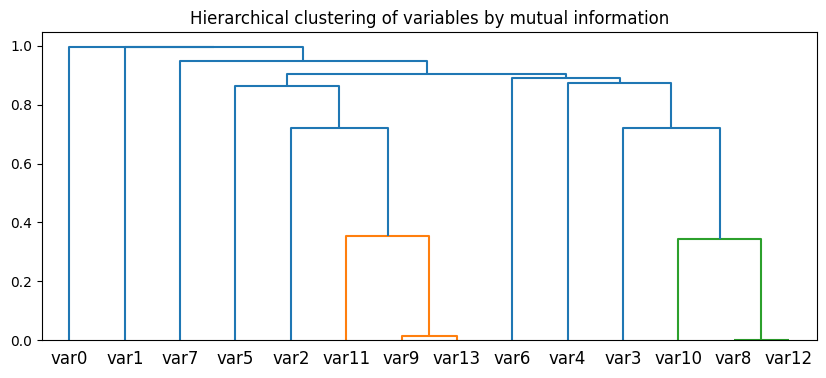

In [26]:
from sklearn.metrics import mutual_info_score
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

cols = df.columns
n = len(cols)
mi_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)

for i in range(n):
    for j in range(n):
        if i != j:
            mi = mutual_info_score(df.iloc[:, i], df.iloc[:, j])
            mi_matrix.iloc[i, j] = mi

# Hierarchical clustering based on MI
dist = 1 - mi_matrix.fillna(0).values / mi_matrix.fillna(0).max().max()  # normalize and invert
# Convert to condensed distance for linkage
cond_dist = squareform(dist, checks=False) 
Z = linkage(cond_dist, method='average')

plt.figure(figsize=(10,4))
dendrogram(Z, labels=cols)
plt.title("Hierarchical clustering of variables by mutual information")
plt.show()

Chow-Liu Bits: 2017.4, Naive Bits: 3623.6, Compression Factor: 0.557


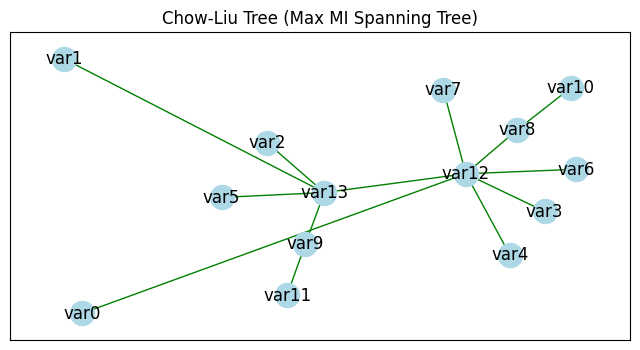

In [27]:
# 1. MI Matrix
from sklearn.metrics import mutual_info_score
cols = df.columns
n = len(cols)
mi_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)
for i in range(n):
    for j in range(n):
        mi_matrix.iloc[i, j] = mutual_info_score(df.iloc[:, i], df.iloc[:, j])

# 2. Chow-Liu Tree (MST with NetworkX)
import networkx as nx
G = nx.Graph()
for i in range(n):
    for j in range(i+1, n):
        G.add_edge(cols[i], cols[j], weight=mi_matrix.iloc[i, j])
mst = nx.maximum_spanning_tree(G, weight='weight')
root = list(cols)[0]
tree = nx.bfs_tree(mst, root)
parent_map = {child: parent for parent, child in tree.edges()}

# 3. Compute Chow-Liu Model Bits
from scipy.stats import entropy
N = len(df)
def cond_entropy(child, parent):
    vals = []
    for pv in df[parent].unique():
        subset = df[child][df[parent] == pv]
        if len(subset) == 0:
            continue
        pvals = subset.value_counts(normalize=True)
        h = entropy(pvals, base=2)
        vals.append(len(subset) / N * h)
    return sum(vals)
root = list(tree)[0]
total_entropy = entropy(df[root].value_counts(normalize=True), base=2)
for child in cols:
    if child == root:
        continue
    parent = parent_map.get(child, None)
    if parent is not None:
        total_entropy += cond_entropy(child, parent)
total_bits = N * total_entropy

# 4. Compute Naive Encoding Bits (Independent Columns)
marginal_entropy = 0
for col in cols:
    p = df[col].value_counts(normalize=True)
    marginal_entropy += entropy(p, base=2)
uncompressed_bits = N * marginal_entropy

# 5. Report Compression Factor
compression_factor = total_bits / uncompressed_bits
print(f"Chow-Liu Bits: {total_bits:.1f}, Naive Bits: {uncompressed_bits:.1f}, "
      f"Compression Factor: {compression_factor:.3f}")

# 6. Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
nx.draw_networkx(mst, with_labels=True, node_color='lightblue', edge_color='green')
plt.title("Chow-Liu Tree (Max MI Spanning Tree)")
plt.show()

In [28]:

df_delta = df.copy(deep=True)
df_delta["sequence"] = example['sequence']

deltas = []
for seq, group in df_delta.groupby('sequence', sort=False):
    delta_group = group[cols_delta].diff(periods=-1)[:-1].astype(bool)
    delta_group['sequence'] = seq
    deltas.append(delta_group)
df_delta = pd.concat(deltas, axis=0, ignore_index=True)


df_delta

NameError: name 'cols_delta' is not defined

In [ ]:
# Per-variable (column) frequency of change:
var_change_freq = df_delta[cols_delta].mean()

# Overall average (mean across variables):
overall_change_freq = var_change_freq.mean()

# Quantiles across variables:
var_freq_quantiles = var_change_freq.quantile([0.0, 0.25, 0.5, 0.75, 1.0])

print("Per-variable frequency of change:\n", var_change_freq)
print("\nOverall average frequency of change: ", overall_change_freq)
print("\nQuantiles of per-variable change frequency:\n", var_freq_quantiles)


NameError: name 'cols_delta' is not defined

In [ ]:
# Number of features changed in each delta row (per step)
delta_row_sums = df_delta[cols_delta].sum(axis=1) / 14

# Average & quantiles per delta-row:
mean_changes_per_row = delta_row_sums.mean()
row_change_quantiles = delta_row_sums.quantile([0.0, 0.25, 0.5, 0.75, 1.0])

print("\nMean number of changes per delta row:", mean_changes_per_row)
print("\nQuantiles of number of changes per delta row:\n", row_change_quantiles)

In [ ]:
def upper_triangle_to_series_tuple_index(df):
    """
    Extract the upper triangular (excluding diagonal) of a square DataFrame to a Series.
    Index is a tuple (row, col).
    """
    values = {}
    cols = df.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            idx = (cols[i], cols[j])
            values[idx] = df.iloc[i, j]
    return pd.Series(values)



def series_stats(s, quantiles=[0, 0.25, 0.5, 0.75, 1.0]):
    """
    Computes mean, variance, and specified quantiles for a pandas Series.
    Returns a dictionary with results.
    """
    stats = {
        'mean': s.mean(),
        'variance': s.var()
    }
    qs = s.quantile(quantiles)
    for q, v in zip(quantiles, qs):
        stats[f'{int(q*100)}%' if q != 0.5 else '50% (median)'] = v
    return stats





# State Packing


In [ ]:
import numpy as np
from typing import List

def pack_state_variables(variables: List[int], domain_sizes: List[int]) -> List[np.uint32]:
    """
    Packs variable values into as few uint32s as possible.
    
    Parameters
    ----------
    variables : List[int]
        List of the current variable values.
    domain_sizes : List[int]
        List of domain sizes for each variable (used to infer bits required).
    
    Returns
    -------
    List[np.uint32]
        Packed representation as list of np.uint32 containers.
        
    Example
    -------
    >>> pack_state_variables([5, 20, 1, 4], [2**16, 2**16, 6, 23])
    [np.uint32(...), np.uint32(...)]
    """
    bits_needed = [int(np.ceil(np.log2(size))) for size in domain_sizes]
    
    packed_values = []
    current_container = np.uint32(0)
    current_bit = 0  # Bit position within the current container
    
    for value, bits, dom_size, idx in zip(variables, bits_needed, domain_sizes, range(len(variables))):
        # Safety check
        if value >= dom_size:
            raise ValueError(f"Variable {idx} value {value} exceeds its domain size {dom_size}.")

        if bits > 32:
            raise ValueError(f"Variable {idx} requires more than 32 bits (domain_size={dom_size})")
            
        # If doesn't fit, start new container
        if current_bit + bits > 32:
            packed_values.append(current_container)
            current_container = np.uint32(0)
            current_bit = 0

        # Shift and pack the current value in place
        current_container |= (np.uint32(value) << current_bit)
        current_bit += bits

    packed_values.append(current_container)  # Add the last container

    return packed_values

def unpack_state_variables(packed: List[np.uint32], domain_sizes: List[int]) -> List[int]:
    """
    Unpacks variable values from the packed uint32 representation.
    
    Parameters
    ----------
    packed : List[np.uint32]
        List of packed uint32s.
    domain_sizes : List[int]
        List of domain sizes for each variable.
    
    Returns
    -------
    List[int]
        List of unpacked variable values.
    """
    bits_needed = [int(np.ceil(np.log2(size))) for size in domain_sizes]
    vars_unpacked = []
    container_idx = 0
    bit_pos = 0
    current_container = packed[container_idx]
    
    for bits, dom_size in zip(bits_needed, domain_sizes):
        # If not enough bits remain in the current container, move to the next one
        if bit_pos + bits > 32:
            container_idx += 1
            current_container = packed[container_idx]
            bit_pos = 0
        mask = (1 << bits) - 1
        value = (current_container >> bit_pos) & mask
        vars_unpacked.append(int(value))
        bit_pos += bits
        
    return vars_unpacked


Packed: [np.uint32(1310725), np.uint32(33)]
Unpacked: [5, 20, 1, 4]


# TREE

In [ ]:
from collections import defaultdict
from typing import Any, Dict, Tuple, List, Hashable, Set, Sequence, Union

LeafValue = Union[Tuple[str, Any], None]  # (var, value) or None
NodeValue = Union[int, LeafValue]

class TreeCompressor:
    """
    Compresses fixed-size states with a given variable ordering via recursive subdivision.
    Every node is a tuple of exactly 2 elements, each a pointer (int) or (var, value) tuple (leaf).
    """

    def __init__(self, variable_ordering: Sequence[Union[str, int]]):
        self.var_order = list(variable_ordering)
        self.subtree_table: Dict[Hashable, int] = {}
        self.id_to_subtree: Dict[int, Tuple[NodeValue, NodeValue]] = {}
        self.next_id: int = 0
        # Statistics
        self.node_share_count: Dict[int, int] = defaultdict(int)
        self.node_share_levels: Dict[int, Set[int]] = defaultdict(set)

    def _get_subtree_id(self, node: Tuple[NodeValue, NodeValue], level: int) -> int:
        node_key = self._make_hashable(node)
        if node_key in self.subtree_table:
            node_id = self.subtree_table[node_key]
            self.node_share_count[node_id] += 1
            self.node_share_levels[node_id].add(level)
            return node_id
        else:
            node_id = self.next_id
            self.next_id += 1
            self.subtree_table[node_key] = node_id
            self.id_to_subtree[node_id] = node
            self.node_share_levels[node_id].add(level)
            return node_id

    def _make_hashable(self, obj: Any) -> Hashable:
        if isinstance(obj, (str, int, float, bool, type(None), np.int64, np.int32)):
            return obj
        elif isinstance(obj, tuple):
            return tuple(self._make_hashable(x) for x in obj)
        elif isinstance(obj, list):
            return tuple(self._make_hashable(x) for x in obj)
        elif isinstance(obj, dict):
            return tuple((k, self._make_hashable(obj[k])) for k in self.var_order if k in obj)
        else:
            raise TypeError(f"Unsupported state type: {type(obj)}")

    def compress(self, state: Union[List[Any], Dict[Any, Any]], ordering: List[Any] = None, level: int = 0) -> int:
        """
        Recursively compress state. Each node stores exactly two fields, 
        each a pointer or a (var, value) pair.
        """
        if ordering is None:
            ordering = self.var_order
        n = len(ordering)
        # Leaf cases: 1 or 2 variables
        if n == 0:
            # Empty slot
            return self._get_subtree_id((None, None), level)
        elif n == 1:
            idx = ordering[0]
            val = state[idx] if isinstance(state, list) else state[idx]
            return self._get_subtree_id(((idx, val), None), level)
        elif n == 2:
            idx1, idx2 = ordering
            val1 = state[idx1] if isinstance(state, list) else state[idx1]
            val2 = state[idx2] if isinstance(state, list) else state[idx2]
            return self._get_subtree_id(((idx1, val1), (idx2, val2)), level)
        else:
            # Split ordering approximately in half
            mid = n // 2
            left_order, right_order = ordering[:mid], ordering[mid:]
            left_id = self.compress(state, left_order, level + 1)
            right_id = self.compress(state, right_order, level + 1)
            return self._get_subtree_id((left_id, right_id), level)

    

    def decompress(self, node_id: int, ordering: List[Any] = None) -> Dict[Any, Any]:
        """
        Reconstruct state as dict following the same ordering.
        """
        if ordering is None:
            ordering = self.var_order

        def _rebuild(node, ordering):
            n = len(ordering)
            if n == 0:
                return dict()
            elif n == 1:
                var_val, _ = node
                var, val = var_val
                return {var: val}
            elif n == 2:
                (var1, val1), (var2, val2) = node
                return {var1: val1, var2: val2}
            else:
                mid = n // 2
                left_order, right_order = ordering[:mid], ordering[mid:]
                left, right = node
                left_dict = _rebuild(self.id_to_subtree[left], left_order)
                right_dict = _rebuild(self.id_to_subtree[right], right_order)
                return {**left_dict, **right_dict}

        root = self.id_to_subtree[node_id]
        return _rebuild(root, ordering)

    @property
    def node_count(self) -> int:
        return len(self.id_to_subtree)

    def compute_tree_statistics(self) -> dict:
        """
        Computes overall statistics for the compressed tree.

        Returns
        -------
        stats : dict
            Dictionary containing fields:
                - 'total_unique_nodes': int
                - 'shared_nodes': int           # nodes used more than once
                - 'total_node_reuse': int       # sum of all node shared counts
                - 'avg_times_node_is_shared': float   # average for nodes with share > 0
                - 'num_variables': int
        """
        total_unique_nodes = len(self.id_to_subtree)
        shared_counts = list(self.node_share_count.values())
        shared_nodes = sum(1 for count in shared_counts if count > 0)
        total_node_reuse = sum(shared_counts)
        avg_times_node_is_shared = (
            total_node_reuse / shared_nodes if shared_nodes else 0.0
        )
        num_variables = len(self.var_order) if hasattr(self, 'var_order') else 0

        return {
            "total_unique_nodes": total_unique_nodes,
            "shared_nodes": shared_nodes,
            "total_node_reuse": total_node_reuse,
            "avg_times_node_is_shared": avg_times_node_is_shared,
            "num_variables": num_variables,
        }

    def print_statistics(self):
        """
        Prints aggregated statistics about the shape and sharing of the compressed tree.
        - For each level: how many unique nodes, how many are shared (used >1 time).
        - Overall totals.
        """
        from collections import defaultdict

        # Aggregation dicts: level -> set of node_ids; level -> list of share counts
        level_node_ids = defaultdict(set)
        level_share_counts = defaultdict(list)

        # Gather info for each node
        for node_id, levels in self.node_share_levels.items():
            for lvl in levels:
                level_node_ids[lvl].add(node_id)
                level_share_counts[lvl].append(self.node_share_count.get(node_id, 0))
        # Compute global stats
        tree_stats = self.compute_tree_statistics()
        total_nodes = tree_stats['total_unique_nodes']
        shared_nodes = tree_stats['shared_nodes']
        total_shares = tree_stats['total_node_reuse']
        average_share = tree_stats['avg_times_node_is_shared']

        print(f"Variable ordering: {self.var_order}")
        print("\nPer-level node statistics:")
        print("{:>7} {:>15} {:>15} {:>15}".format("Level", "Unique nodes", "Shared nodes", "Total shares"))
        for lvl in sorted(level_node_ids):
            n_unique = len(level_node_ids[lvl])
            n_shared = sum(1 for cid in level_node_ids[lvl] if self.node_share_count.get(cid, 0) > 0)
            n_shares = sum(self.node_share_count.get(cid, 0) for cid in level_node_ids[lvl])
            print("{:>7} {:>15} {:>15} {:>15}".format(lvl, n_unique, n_shared, n_shares))

        print("\nOverall tree statistics:")
        print(f"  Total unique nodes: {total_nodes}")
        print(f"  Nodes shared (>1 use): {shared_nodes}")
        print(f"  Total node reuse count: {total_shares}")
        print(f"  Avg. times a shared node is reused: {average_share:.2f}")

# Example usage
if __name__ == "__main__":
    var_order = [0, 1, 2, 3]
    compressor = TreeCompressor(var_order)


    id1 = compressor.compress([1, 9, 3, 7])
    id2 = compressor.compress([1, 9, 5, 7])
    id3 = compressor.compress([1, 9, 3, 7])

    compressor.print_statistics()

    print("Restored state1:", compressor.decompress(id1))

Variable ordering: [0, 1, 2, 3]

Per-level node statistics:
  Level    Unique nodes    Shared nodes    Total shares
      0               2               1               1
      1               3               2               3

Overall tree statistics:
  Total unique nodes: 5
  Nodes shared (>1 use): 3
  Total node reuse count: 4
  Avg. times a shared node is reused: 1.33
Restored state1: {0: 1, 1: 9, 2: 3, 3: 7}


In [30]:
from typing import List, Dict, Any, Sequence, Union

def greedy_variable_ordering(
    states: List[Union[dict, list]],
    variables: Sequence[Any] = None
) -> List[Any]:
    """
    Greedily order variables to maximize subtree sharing,
    using variable names/keys rather than relying on index.

    Converts all states to dicts with variable keys for robust access.

    Parameters
    ----------
    states : List[dict or list]
        The collection of states to be compressed.
    variables : Sequence[Any], optional
        Which variables to consider. If None, inferred from the first state.

    Returns
    -------
    ordering : List[Any]
        Greedy ordering of variable keys.
    """
    if not states:
        return []

    # Standardize input to list of dicts mapping key/index -> value
    if isinstance(states[0], dict):
        states_dicts = [s.copy() for s in states]  # Safe shallow copy
        if variables is None:
            variables = list(states_dicts[0].keys())
    else:
        if variables is None:
            variables = list(range(len(states[0])))
        states_dicts = [{k: v for k, v in zip(variables, s)} for s in states]

    remaining_vars = set(variables)
    ordering = []
    sub_states = states_dicts

    while remaining_vars:
        best_var = None
        best_score = None

        for var in remaining_vars:
            groups = {}
            for s in sub_states:
                v = s[var]
                groups.setdefault(v, []).append(s)
            # Unique sub-states remaining after removing this variable
            unique_substates = set()
            for group in groups.values():
                for g in group:
                    key_tuple = tuple(
                        sorted(
                            (k, g[k]) for k in g if k != var
                        )
                    )
                    unique_substates.add(key_tuple)
            score = len(unique_substates)
            if best_score is None or score < best_score:
                best_var = var
                best_score = score
        ordering.append(best_var)
        remaining_vars.remove(best_var)
        sub_states = [{k: v for k, v in s.items() if k != best_var}
                      for s in sub_states]

    return ordering

In [31]:
from typing import List, Any, Union
import itertools

def _states_projection(states, block):
    """Project states on the given variable names or indices in block."""
    first = states[0]
    if isinstance(first, dict):
        return [tuple(s[k] for k in block) for s in states]
    else:
        return [tuple(s[k] for k in block) for s in states]

def _unique_count(states, blocks):
    """Number of unique subtrees for a series of blocks."""
    projections = []
    first = states[0]
    for s in states:
        row = []
        for block in blocks:
            if isinstance(first, dict):
                row.append(tuple(s[k] for k in block))
            else:
                row.append(tuple(s[k] for k in block))
        projections.append(tuple(row))
    return len(set(projections))

def greedy_variable_order(states: List[Union[dict, list]], variables: List[Any] = None) -> List[Any]:
    """
    Globally greedy pairwise merging of variable blocks:
    At each step, merges the pair of variable blocks resulting in the smallest
    number of unique projected subtrees. Not restricted to adjacent blocks.

    Returns
    -------
    List[Any]
        Variable order maximizing subtree sharing for the supplied states.
    """
    if not states:
        return []
    if variables is None:
        first = states[0]
        variables = list(first.keys()) if isinstance(first, dict) else list(range(len(first)))
    # Start with each variable as its own block
    blocks = [[v] for v in variables]
    while len(blocks) > 1:
        best_score = None
        best_i, best_j = None, None
        for i, j in itertools.combinations(range(len(blocks)), 2):
            merged = [blocks[k] for k in range(len(blocks)) if k not in (i, j)] + [blocks[i] + blocks[j]]
            score = _unique_count(states, merged)
            if best_score is None or score < best_score:
                best_score = score
                best_i, best_j = i, j
        # Merge best pair
        new_block = blocks[best_i] + blocks[best_j]
        blocks = [blocks[k] for k in range(len(blocks)) if k not in (best_i, best_j)] + [new_block]
    return blocks[0]

In [32]:
def test_order(var_order = list(range(14))):
    test_df = df.copy(deep=True)
    compressor = TreeCompressor(var_order)
    for index, row in test_df.iterrows():
        compressor.compress(row)
    compressor.print_statistics()

    del compressor

display(Markdown("## Tree size depending on variable order:"))

display(Markdown("### Original Order:"))
print(test_order())

display(Markdown("### Entropy Order:"))

print(test_order(greedy_variable_ordering(df.values.tolist())))


## Tree size depending on variable order:

### Original Order:

Variable ordering: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

Per-level node statistics:
  Level    Unique nodes    Shared nodes    Total shares
      0             199               0               0
      1             139              91             259
      2              83              72             713
      3              72              65            1520

Overall tree statistics:
  Total unique nodes: 493
  Nodes shared (>1 use): 228
  Total node reuse count: 2492
  Avg. times a shared node is reused: 10.93
None


/tmp/ipykernel_9162/4158456319.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val = state[idx] if isinstance(state, list) else state[idx]
/tmp/ipykernel_9162/4158456319.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val1 = state[idx1] if isinstance(state, list) else state[idx1]
/tmp/ipykernel_9162/4158456319.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val2 = state[idx2] if isinstance(state, list) else state[idx2

### Entropy Order:

Variable ordering: [1, 0, 13, 12, 5, 7, 6, 2, 3, 8, 10, 4, 9, 11]

Per-level node statistics:
  Level    Unique nodes    Shared nodes    Total shares
      0             199               0               0
      1             207               8             191
      2             106              93             690
      3              60              60            1532

Overall tree statistics:
  Total unique nodes: 572
  Nodes shared (>1 use): 161
  Total node reuse count: 2413
  Avg. times a shared node is reused: 14.99
None


In [33]:
greedy_variable_order(df.reindex(columns=["var1","var0", ] + [f"var{i}" for i in range(2,14)]).values.tolist())

[12, 13, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [34]:
df

,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13
1,0,2,1,1,0,0,0,0,1,0,0,0,7,6
2,1,2,1,1,0,0,0,0,1,0,0,0,7,6
3,2,2,1,1,0,0,0,0,1,0,0,0,7,6
4,0,0,1,1,0,0,0,0,1,0,0,0,7,6
5,0,1,1,1,0,0,0,0,1,0,0,0,7,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2,2,0,0,1,0,0,1,3,2,1,0,4,8
196,2,2,0,0,0,1,1,0,3,3,1,1,2,3
197,0,2,1,0,0,0,1,0,0,3,0,1,6,3
198,0,2,0,1,0,1,0,0,3,1,1,0,2,7


In [35]:
from typing import List, Any, Union
import itertools

def _states_projection(states, block):
    first = states[0]
    if isinstance(first, dict):
        return [tuple(s[k] for k in block) for s in states]
    else:
        return [tuple(s[k] for k in block) for s in states]

def _unique_count(states, blocks):
    projections = []
    first = states[0]
    for s in states:
        row = []
        for block in blocks:
            if isinstance(first, dict):
                row.append(tuple(s[k] for k in block))
            else:
                row.append(tuple(s[k] for k in block))
        projections.append(tuple(row))
    return len(set(projections))

def globally_worst_variable_order(states: List[Union[dict, list]], variables: List[Any] = None) -> List[Any]:
    """
    Greedily merges the pair of variable blocks that results in the LARGEST number
    of unique projected subtrees at each step (best for fragmentation/worst for compression).
    
    Returns
    -------
    List[Any]
        Variable order minimizing subtree sharing for the supplied states.
    """
    if not states:
        return []
    first = states[0]
    if variables is None:
        variables = list(first.keys()) if isinstance(first, dict) else list(range(len(first)))
    blocks = [[v] for v in variables]
    while len(blocks) > 1:
        worst_score = None
        worst_i, worst_j = None, None
        for i, j in itertools.combinations(range(len(blocks)), 2):
            merged = [blocks[k] for k in range(len(blocks)) if k not in (i, j)] + [blocks[i] + blocks[j]]
            score = _unique_count(states, merged)
            if worst_score is None or score > worst_score:
                worst_score = score
                worst_i, worst_j = i, j
        # Merge worst pair
        new_block = blocks[worst_i] + blocks[worst_j]
        blocks = [blocks[k] for k in range(len(blocks)) if k not in (worst_i, worst_j)] + [new_block]
    return blocks[0]

In [36]:
import itertools
from typing import List, Any, Union
import numpy as np
import pandas as pd
from scipy.stats import entropy

def _get_block_columns(states, block):
    """Returns np.ndarray where each row is the values of one state for variables in block."""
    if isinstance(states[0], dict):
        return np.array([[s[k] for k in block] for s in states])
    else:
        return np.array([[s[k] for k in block] for s in states])

def _entropy(cols: np.ndarray) -> float:
    """Entropy of a multivariate block."""
    df = pd.DataFrame(cols)
    _, counts = np.unique(df.to_records(index=False), return_counts=True, axis=0)
    probs = counts / counts.sum()
    return entropy(probs, base=2)

def _mutual_information(states, block1, block2) -> float:
    """Compute mutual information I(block1; block2) from the dataset of states."""
    X = _get_block_columns(states, block1)
    Y = _get_block_columns(states, block2)
    XY = np.hstack((X, Y))
    H_X = _entropy(X)
    H_Y = _entropy(Y)
    H_XY = _entropy(XY)
    # MI = H(X) + H(Y) - H(XY)
    return H_X + H_Y - H_XY

def greedy_mi_max_variable_order(states: List[Union[dict,list]], variables: List[Any]=None) -> List[Any]:
    """
    Greedily merges variable blocks that have the highest mutual information.
    
    Parameters
    ----------
    states : list of dict or list
        States as dicts or lists.
    variables : list, optional
        If not provided, inferred from data.
    
    Returns
    -------
    List[Any]
        Optimal variable reordering (high shared information earlier).
    """
    if not states:
        return []
    first = states[0]
    if variables is None:
        variables = list(first.keys()) if isinstance(first, dict) else list(range(len(first)))
    blocks = [[v] for v in variables]
    while len(blocks) > 1:
        best_mi = None
        best_pair = None
        for i, j in itertools.combinations(range(len(blocks)), 2):
            mi = _mutual_information(states, blocks[i], blocks[j])
            if best_mi is None or mi > best_mi:
                best_mi = mi
                best_pair = (i, j)
        # Merge the best pair
        i, j = best_pair
        merged_block = blocks[i] + blocks[j]
        # Remove both, append merged
        blocks = [blocks[k] for k in range(len(blocks)) if k not in (i,j)] + [merged_block]
    return blocks[0]

In [52]:
import numpy as np

order_tuples = [
    ('Identity', list(range(14))),
    ('Greedy Variable Ordering', greedy_variable_ordering(df.values.tolist())),
    ('Greedy Variable Tree Ordering', greedy_variable_order(df.values.tolist())),
    ('Greedy Max Entropy Variable Order', globally_worst_variable_order(df.values.tolist())),
    ('Greedy Mutual Information', greedy_mi_max_variable_order(df.values.tolist())),
    ('Random (1)', np.random.permutation(range(14)).tolist()),
    ('Random (2)', np.random.permutation(range(14)).tolist()),
    ('Random (3)', np.random.permutation(range(14)).tolist()),
    ('Random (4)', np.random.permutation(range(14)).tolist()),
    ('Random (5)', np.random.permutation(range(14)).tolist()),
]

results = []
for name, order in order_tuples:

    print("="*50)
    print(name)
    compressor = TreeCompressor(order)
    ids = [compressor.compress(s) for s in df.values.tolist()]
    compressor.print_statistics()      # Or capture print_statistics() as discussed before
    print("="*50)
    print("\n"*5)


Identity
Variable ordering: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

Per-level node statistics:
  Level    Unique nodes    Shared nodes    Total shares
      0             199               0               0
      1             139              91             259
      2              83              72             713
      3              72              65            1520

Overall tree statistics:
  Total unique nodes: 493
  Nodes shared (>1 use): 228
  Total node reuse count: 2492
  Avg. times a shared node is reused: 10.93






Greedy Variable Ordering
Variable ordering: [1, 0, 13, 12, 5, 7, 6, 2, 3, 8, 10, 4, 9, 11]

Per-level node statistics:
  Level    Unique nodes    Shared nodes    Total shares
      0             199               0               0
      1             207               8             191
      2             106              93             690
      3              60              60            1532

Overall tree statistics:
  Total unique nodes: 572
  No

# Python State Analytics Script


In [36]:
import pandas as pd
import numpy as np
import pathlib
from pathlib import Path
from glob import glob
import json
import os
from dataclasses import dataclass
import itertools
from collections import defaultdict
from typing import List, Dict, Any, Union,  Hashable, Set, Sequence, Tuple
from scipy.stats import entropy
import random 
import math

@dataclass
class Run:
    domain: str
    problem: str
    solved: bool
    var_df: pd.DataFrame
    pck_df: pd.DataFrame
    sequence: pd.Series
    domain_sizes: pd.Series

LeafValue = Union[Tuple[str, Any], None]  # (var, value) or None
NodeValue = Union[int, LeafValue]

class TreeCompressor:
    """
    Compresses fixed-size states with a given variable ordering via recursive subdivision.
    Every node is a tuple of exactly 2 elements, each a pointer (int) or (var, value) tuple (leaf).
    """

    def __init__(self, variable_ordering: Sequence[Union[str, int]]):
        self.var_order = list(variable_ordering)
        self.subtree_table: Dict[Hashable, int] = {}
        self.id_to_subtree: Dict[int, Tuple[NodeValue, NodeValue]] = {}
        self.next_id: int = 0
        # Statistics
        self.node_share_count: Dict[int, int] = defaultdict(int)
        self.node_share_levels: Dict[int, Set[int]] = defaultdict(set)

    def _get_subtree_id(self, node: Tuple[NodeValue, NodeValue], level: int) -> int:
        node_key = self._make_hashable(node)
        if node_key in self.subtree_table:
            node_id = self.subtree_table[node_key]
            self.node_share_count[node_id] += 1
            self.node_share_levels[node_id].add(level)
            return node_id
        else:
            node_id = self.next_id
            self.next_id += 1
            self.subtree_table[node_key] = node_id
            self.id_to_subtree[node_id] = node
            self.node_share_levels[node_id].add(level)
            return node_id

    def _make_hashable(self, obj: Any) -> Hashable:
        if isinstance(obj, (str, int, float, bool, type(None), np.int64, np.int32)):
            return obj
        elif isinstance(obj, tuple):
            return tuple(self._make_hashable(x) for x in obj)
        elif isinstance(obj, list):
            return tuple(self._make_hashable(x) for x in obj)
        elif isinstance(obj, dict):
            return tuple((k, self._make_hashable(obj[k])) for k in self.var_order if k in obj)
        else:
            raise TypeError(f"Unsupported state type: {type(obj)}")

    def compress(self, state: Union[List[Any], Dict[Any, Any]], ordering: List[Any] = None, level: int = 0) -> int:
        """
        Recursively compress state. Each node stores exactly two fields, 
        each a pointer or a (var, value) pair.
        """
        if ordering is None:
            ordering = self.var_order
        n = len(ordering)
        # Leaf cases: 1 or 2 variables
        if n == 0:
            # Empty slot
            return self._get_subtree_id((None, None), level)
        elif n == 1:
            idx = ordering[0]
            val = state[idx] if isinstance(state, list) else state[idx]
            return self._get_subtree_id(((idx, val), None), level)
        elif n == 2:
            idx1, idx2 = ordering
            val1 = state[idx1] if isinstance(state, list) else state[idx1]
            val2 = state[idx2] if isinstance(state, list) else state[idx2]
            return self._get_subtree_id(((idx1, val1), (idx2, val2)), level)
        else:
            # Split ordering approximately in half
            mid = n // 2
            left_order, right_order = ordering[:mid], ordering[mid:]
            left_id = self.compress(state, left_order, level + 1)
            right_id = self.compress(state, right_order, level + 1)
            return self._get_subtree_id((left_id, right_id), level)

    @property
    def node_count(self) -> int:
        return len(self.id_to_subtree)

    def compute_tree_statistics(self) -> dict:
        """
        Computes overall statistics for the compressed tree.

        Returns
        -------
        stats : dict
            Dictionary containing fields:
                - 'total_unique_nodes': int
                - 'shared_nodes': int           # nodes used more than once
                - 'total_node_reuse': int       # sum of all node shared counts
                - 'avg_times_node_is_shared': float   # average for nodes with share > 0
                - 'num_variables': int
        """
        total_unique_nodes = len(self.id_to_subtree)
        shared_counts = list(self.node_share_count.values())
        shared_nodes = sum(1 for count in shared_counts if count > 0)
        total_node_reuse = sum(shared_counts)
        avg_times_node_is_shared = (
            total_node_reuse / shared_nodes if shared_nodes else 0.0
        )
        num_variables = len(self.var_order) if hasattr(self, 'var_order') else 0

        return {
            "total_unique_nodes": total_unique_nodes,
            "shared_nodes": shared_nodes,
            "total_node_reuse": total_node_reuse,
            "avg_times_node_is_shared": avg_times_node_is_shared,
            "num_variables": num_variables,
        }

def read_states_run(run_path: pathlib.PosixPath):
    properties_file = run_path / "static-properties"
    state_file = run_path / "state_data.csv"
    plan_file = run_path / "sas_plan"
    if not os.path.isfile(properties_file) or \
        not os.path.isfile(state_file):
        return pd.DataFrame()

    properties = None
    with open(properties_file) as file:
        properties = json.load(file)
    
    df = pd.read_csv(state_file)
    df['domain'] = properties['domain']
    df['problem'] = properties['problem']
    df['solved'] = os.path.isfile(plan_file)
    return df

def read_states_domain(exp_data: pathlib.PosixPath):
    search_glob = map(Path, glob(str(exp_data / "runs-*" / "*")))
    
    dfs = []
    for run_path in search_glob:
        dfs.append(read_states_run(run_path))
    return dfs
    
def preprocess_df(df) -> Run:
    """
    Preprocesses a DataFrame for a run, extracting domain/problem info,
    states, variable and packet dataframe slices, and prints debug output.

    Returns:
        Run: Dataclass with all extracted and printed fields.
    """
    # Basic info
    domain = df.loc[0, "domain"]
    problem = df.loc[0, "problem"]
    solved = df.loc[0, "solved"]

    # Find all columns between 'var0' and 'domain' (exclusive of 'domain')
    cols = df.columns.tolist()
    var0_idx = cols.index('var0')
    domain_idx = cols.index('domain')

    var_cols = cols[var0_idx:domain_idx]
    buff0_idx = cols.index('buff0')
    pck_cols = cols[buff0_idx:var0_idx]

    # Attempt to extract domain_sizes; assuming domain_sizes in row 0, var_cols
    domain_sizes = df[var_cols].iloc[0]
    var_df = df.loc[1:, var_cols]

    pck_df = df.loc[1:, pck_cols] if pck_cols else pd.DataFrame()

    sequence = df.loc[1:, 'sequence']
    return Run(domain, problem, solved, var_df, pck_df, sequence, domain_sizes)

def _get_block_columns(states, block):
    """Returns np.ndarray where each row is the values of one state for variables in block."""
    if isinstance(states[0], dict):
        return np.array([[s[k] for k in block] for s in states])
    else:
        return np.array([[s[k] for k in block] for s in states])

def _entropy(cols: np.ndarray) -> float:
    """Entropy of a multivariate block."""
    df = pd.DataFrame(cols)
    _, counts = np.unique(df.to_records(index=False), return_counts=True, axis=0)
    probs = counts / counts.sum()
    return entropy(probs, base=2)

def _mutual_information(states, block1, block2) -> float:
    """Compute mutual information I(block1; block2) from the dataset of states."""
    X = _get_block_columns(states, block1)
    Y = _get_block_columns(states, block2)
    XY = np.hstack((X, Y))
    H_X = _entropy(X)
    H_Y = _entropy(Y)
    H_XY = _entropy(XY)
    # MI = H(X) + H(Y) - H(XY)
    return H_X + H_Y - H_XY

def greedy_mi_max_variable_order(states: List[Union[dict,list]], variables: List[Any]=None) -> List[Any]:
    """
    Greedily merges variable blocks that have the highest mutual information.
    
    Parameters
    ----------
    states : list of dict or list
        States as dicts or lists.
    variables : list, optional
        If not provided, inferred from data.
    
    Returns
    -------
    List[Any]
        Optimal variable reordering (high shared information earlier).
    """
    if not states:
        return []
    first = states[0]
    if variables is None:
        variables = list(first.keys()) if isinstance(first, dict) else list(range(len(first)))
    blocks = [[v] for v in variables]
    while len(blocks) > 1:
        best_mi = None
        best_pair = None
        for i, j in itertools.combinations(range(len(blocks)), 2):
            mi = _mutual_information(states, blocks[i], blocks[j])
            if best_mi is None or mi > best_mi:
                best_mi = mi
                best_pair = (i, j)
        # Merge the best pair
        i, j = best_pair
        merged_block = blocks[i] + blocks[j]
        # Remove both, append merged
        blocks = [blocks[k] for k in range(len(blocks)) if k not in (i,j)] + [merged_block]
    return blocks[0]

def _states_projection(states, block):
    first = states[0]
    if isinstance(first, dict):
        return [tuple(s[k] for k in block) for s in states]
    else:
        return [tuple(s[k] for k in block) for s in states]

def _unique_count(states, blocks):
    projections = []
    first = states[0]
    for s in states:
        row = []
        for block in blocks:
            if isinstance(first, dict):
                row.append(tuple(s[k] for k in block))
            else:
                row.append(tuple(s[k] for k in block))
        projections.append(tuple(row))
    return len(set(projections))

def globally_worst_variable_order(states: List[Union[dict, list]], variables: List[Any] = None) -> List[Any]:
    """
    Greedily merges the pair of variable blocks that results in the LARGEST number
    of unique projected subtrees at each step (best for fragmentation/worst for compression).
    
    Returns
    -------
    List[Any]
        Variable order minimizing subtree sharing for the supplied states.
    """
    if not states:
        return []
    first = states[0]
    if variables is None:
        variables = list(first.keys()) if isinstance(first, dict) else list(range(len(first)))
    blocks = [[v] for v in variables]
    while len(blocks) > 1:
        worst_score = None
        worst_i, worst_j = None, None
        for i, j in itertools.combinations(range(len(blocks)), 2):
            merged = [blocks[k] for k in range(len(blocks)) if k not in (i, j)] + [blocks[i] + blocks[j]]
            score = _unique_count(states, merged)
            if worst_score is None or score > worst_score:
                worst_score = score
                worst_i, worst_j = i, j
        # Merge worst pair
        new_block = blocks[worst_i] + blocks[worst_j]
        blocks = [blocks[k] for k in range(len(blocks)) if k not in (worst_i, worst_j)] + [new_block]
    return blocks[0]


def greedy_variable_ordering_tree(states: List[Union[dict, list]], variables: List[Any] = None) -> List[Any]:
    """
    Globally greedy pairwise merging of variable blocks:
    At each step, merges the pair of variable blocks resulting in the smallest
    number of unique projected subtrees. Not restricted to adjacent blocks.

    Returns
    -------
    List[Any]
        Variable order maximizing subtree sharing for the supplied states.
    """
    if not states:
        return []
    if variables is None:
        first = states[0]
        variables = list(first.keys()) if isinstance(first, dict) else list(range(len(first)))
    # Start with each variable as its own block
    blocks = [[v] for v in variables]
    while len(blocks) > 1:
        best_score = None
        best_i, best_j = None, None
        for i, j in itertools.combinations(range(len(blocks)), 2):
            merged = [blocks[k] for k in range(len(blocks)) if k not in (i, j)] + [blocks[i] + blocks[j]]
            score = _unique_count(states, merged)
            if best_score is None or score < best_score:
                best_score = score
                best_i, best_j = i, j
        # Merge best pair
        new_block = blocks[best_i] + blocks[best_j]
        blocks = [blocks[k] for k in range(len(blocks)) if k not in (best_i, best_j)] + [new_block]
    return blocks[0]
    from typing import List, Dict, Any, Sequence, Union

def greedy_variable_ordering_single(
    states: List[Union[dict, list]],
    variables: Sequence[Any] = None
) -> List[Any]:
    """
    Greedily order variables to maximize subtree sharing,
    using variable names/keys rather than relying on index.

    Converts all states to dicts with variable keys for robust access.

    Parameters
    ----------
    states : List[dict or list]
        The collection of states to be compressed.
    variables : Sequence[Any], optional
        Which variables to consider. If None, inferred from the first state.

    Returns
    -------
    ordering : List[Any]
        Greedy ordering of variable keys.
    """
    if not states:
        return []

    # Standardize input to list of dicts mapping key/index -> value
    if isinstance(states[0], dict):
        states_dicts = [s.copy() for s in states]  # Safe shallow copy
        if variables is None:
            variables = list(states_dicts[0].keys())
    else:
        if variables is None:
            variables = list(range(len(states[0])))
        states_dicts = [{k: v for k, v in zip(variables, s)} for s in states]

    remaining_vars = set(variables)
    ordering = []
    sub_states = states_dicts

    while remaining_vars:
        best_var = None
        best_score = None

        for var in remaining_vars:
            groups = {}
            for s in sub_states:
                v = s[var]
                groups.setdefault(v, []).append(s)
            # Unique sub-states remaining after removing this variable
            unique_substates = set()
            for group in groups.values():
                for g in group:
                    key_tuple = tuple(
                        sorted(
                            (k, g[k]) for k in g if k != var
                        )
                    )
                    unique_substates.add(key_tuple)
            score = len(unique_substates)
            if best_score is None or score < best_score:
                best_var = var
                best_score = score
        ordering.append(best_var)
        remaining_vars.remove(best_var)
        sub_states = [{k: v for k, v in s.items() if k != best_var}
                      for s in sub_states]

    return ordering

    
def pack_values_to_uint32(values: list, domain_sizes: list) -> list:
    """
    Pack a list of integer values into as few uint32s as possible, with each value using
    only as many bits as needed, and no value spanning across two uint32s.
    """
    assert len(values) == len(domain_sizes), "Lists must be the same length."
    bit_lengths = [math.ceil(math.log2(max(1, dom_size))) for dom_size in domain_sizes]
    packed = []
    current = 0  # current uint32 accumulator
    bits_used = 0  # bits currently used in this uint32
    for v, bits in zip(values, bit_lengths):
        if bits_used + bits > 32:
            packed.append(current & 0xFFFFFFFF)
            current = 0
            bits_used = 0
        current |= (v & ((1 << bits) - 1)) << bits_used
        bits_used += bits
    if bits_used > 0:
        packed.append(current & 0xFFFFFFFF)
    return packed

def aggregate_random_order_stats(run, states, representation, n_random=10, random_seed=42):
    """
    For one run and set of states, generate statistics over N random variable orderings.
    Aggregates with mean, std, min, max.

    Returns: list of dicts, one per aggregate (mean/std/min/max) for this run.
    """
    import numpy as np
    import random
    from collections import defaultdict

    rng = random.Random(random_seed)
    num_vars = len(states[0])
    field_collections = defaultdict(list)
    for _ in range(n_random):
        ordering = rng.sample(list(range(num_vars)), num_vars)
        compressor = TreeCompressor(ordering)
        for state in states:
            compressor.compress(state)
        stats = compressor.compute_tree_statistics()
        for key, value in stats.items():
            field_collections[key].append(value)
    results = []
    for agg_func, funcname in [
        (np.mean, "mean"),
        (np.std, "std"),
        (np.min, "min"),
        (np.max, "max"),
    ]:
        agg_stats = {field: float(agg_func(vals)) for field, vals in field_collections.items()}
        results.append({
            "domain": run.domain,
            "problem": run.problem,
            "solved": run.solved,
            "ordering_name": f"Random ({funcname}, N={n_random})",
            "representation": representation,
            "ordering": None,
            **agg_stats,
        })
    return results



def gather_statistics(runs: list) -> list:
    """
    For each Run, iterates through different variable ordering strategies,
    compresses the states, collects tree and ordering statistics.
    Returns a list of result dicts (one per run/ordering).
    """
    results = []
    order_methods = [
        ('Identity',                          lambda run: list(range(run.var_df.shape[1]))),
        ('Greedy Variable Ordering',          lambda run: greedy_variable_ordering_single(run.var_df.values.tolist())),
        ('Greedy Variable Tree Ordering',     lambda run: greedy_variable_ordering_tree(run.var_df.values.tolist())),
        ('Greedy Max Entropy Variable Order', lambda run: globally_worst_variable_order(run.var_df.values.tolist())),
        ('Greedy Mutual Information',         lambda run: greedy_mi_max_variable_order(run.var_df.values.tolist())),
    ]

    for run in runs:
        states_unpacked = run.var_df.values.tolist()
        # Packed states: each state packed per domain_sizes
        states_packed = [pack_values_to_uint32(state, run.domain_sizes) for state in states_unpacked]
        
        for representation, states in [("unpacked", states_unpacked), ("packed", states_packed)]:
            states = run.var_df.values.tolist()  # States as lists
            for order_name, order_fn in order_methods:
                ordering = order_fn(run)
                compressor = TreeCompressor(ordering)
                for state in states:
                    compressor.compress(state)
                stats = compressor.compute_tree_statistics()
                results.append({
                    "domain": run.domain,
                    "problem": run.problem,
                    "solved": run.solved,
                    "ordering_name": order_name,
                    "representation": representation,
                    "ordering": ordering,
                    **stats,  # flatten the stats into the dict
                })

            # Aggregate over random orderings
            agg_random_rows = aggregate_random_order_stats(run, states, representation, n_random=20, random_seed=42)
            results.extend(agg_random_rows)
    
    return results

def main():
    # You can replace this path with an experiment folder
    exp_path = pathlib.Path('./data/2025-04-20-A-state_extraction')
    run_dfs = read_states_domain(exp_path)
    runs = []
    for df in run_dfs[0:1]:
        # Defensive: skip empty frames
        if not df.empty:
            # You may need to fix preprocess_df if sequence/domain_sizes extraction fails
            runs.append(preprocess_df(df))
    # Gather statistics
    stats = gather_statistics(runs)
    # Print or save as DataFrame/JSON
    stats_df = pd.DataFrame(stats)
    print(stats_df)
    # Optionally save
    stats_df.to_csv("statistics_results.csv", index=False)
    # or: with open("statistics_results.json", "w") as f: json.dump(stats, f, indent=2)

if __name__ == "__main__":  
    main()

   domain   problem  solved                      ordering_name representation  \
0   depot  p01.pddl    True                           Identity       unpacked   
1   depot  p01.pddl    True           Greedy Variable Ordering       unpacked   
2   depot  p01.pddl    True      Greedy Variable Tree Ordering       unpacked   
3   depot  p01.pddl    True  Greedy Max Entropy Variable Order       unpacked   
4   depot  p01.pddl    True          Greedy Mutual Information       unpacked   
5   depot  p01.pddl    True                Random (mean, N=20)       unpacked   
6   depot  p01.pddl    True                 Random (std, N=20)       unpacked   
7   depot  p01.pddl    True                 Random (min, N=20)       unpacked   
8   depot  p01.pddl    True                 Random (max, N=20)       unpacked   
9   depot  p01.pddl    True                           Identity         packed   
10  depot  p01.pddl    True           Greedy Variable Ordering         packed   
11  depot  p01.pddl    True 